# FedTGP* 详细参数对比分析

本 Notebook 专门用于分析 **FedTGP*** 算法在不同超参数配置下的表现。我们将从 Lambda、本地训练轮数、学习率以及服务端 TGP 参数等多个维度进行详细对比。

In [6]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
from utils import ResultLoader, plot_results, plot_results_split, plot_loss

# 设置绘图风格
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,
    'figure.titlesize': 20
})

loader = ResultLoader("../results")
algo = 'fedtgp3'
loader.algo_patterns[algo] = lambda args: f"_{args['lamda_']}_{args['head_epochs']}_{args['body_epochs']}_{args['lr_head']}_{args['lr_body']}_{args['server_epochs']}_{args['server_lr']}_{args['margin_threshold']}"

In [19]:
def load_and_plot_comparison(algo_name, param_name, param_values, common_args, x_lim=100, metric="acc"):
    """
    加载并绘制特定参数对比的通用函数
    """
    results = {}
    for val in param_values:
        args = common_args.copy()
        args[param_name] = val
        label = f"{param_name}={val}"
        data = loader.load(algo_name, **args, specific_run=0)
        if data:
            results[label] = data
        else:
            print(f"  [Warning] 未找到结果: {label}")

    if results:
        title = f"Comparison of {param_name} on {common_args['dataset']}"
        plot_results_split(results, x_lim, metric=metric, title=title, label_name=param_name)
    else:
        print("No results to plot.")

## 快速查看指定参数结果

在此单元格手动输入一组参数，直接加载并对比其表现。

Figure saved to figures/split_manual_check:_fedtgp3.png

Summary of ACC:
--------------------------------------------------------------------------------
Param                |    Model Max | Model Last10 |    Proto Max | Proto Last10
--------------------------------------------------------------------------------
ACC                  |      85.6243 |      85.1178 |      85.5397 |      84.3930
--------------------------------------------------------------------------------


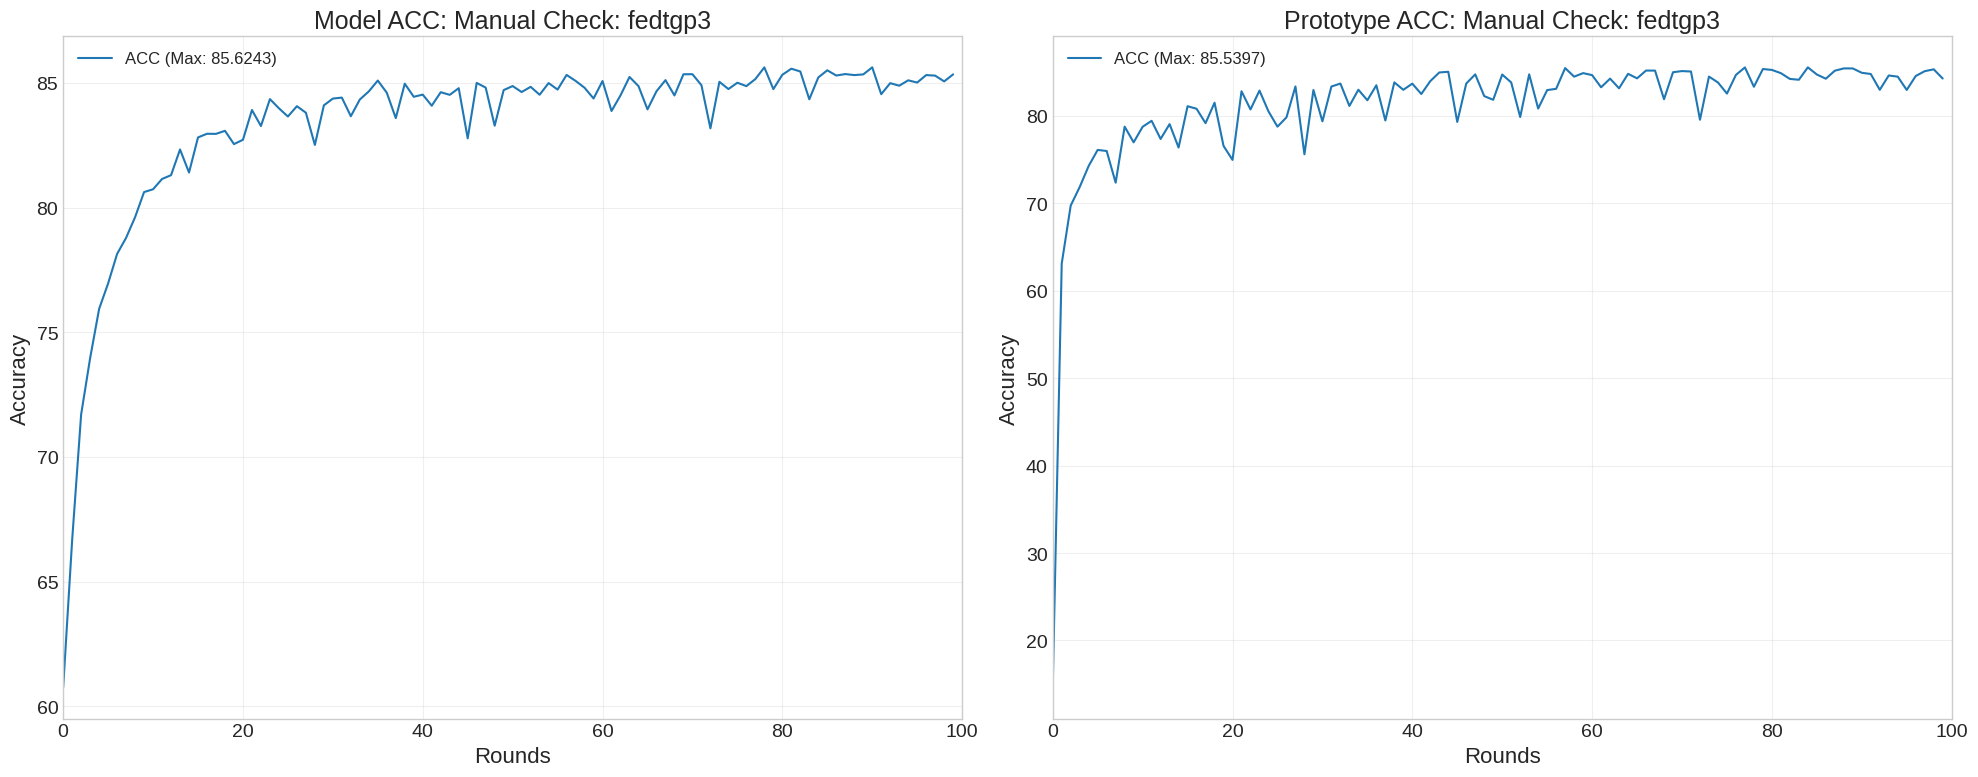

In [22]:
# ================== 指定观测参数 ==================
target_args = {
    "dataset": "cifar10",
    "partition": "dirichlet",
    "alpha": 0.1,
    "num_clients": 10,
    "model": "cnn",
    "epochs": 1,
    "batch_size": 64,
    "lr": 0.01,
    "lamda_": 100.0,
    "head_epochs": 10,
    "body_epochs": 2,
    "lr_head": 0.01,
    "lr_body": 0.01,
    "server_epochs": 100,
    "server_lr": 0.01,
    "margin_threshold": 100.0
}
# ================================================

data = loader.load(algo, **target_args, specific_run=0)
if data:
    results = {"ACC": data}
    plot_results_split(results, x_lim=100, metric="acc", title=f"Manual Check: {algo}", label_name="Param")
else:
    print("[Error] 未找到指定参数的结果，请检查路径。")


## 单元格 1: Lambda ($\lambda$) 对比

$\lambda$ 控制特征提取器与全局原型的对齐强度。

  [Error] Failed to load ../results/fedtgp3/cifar10_dirichlet_10_0.1/1_64_0.01_0.1_10_2_0.01_0.01_100_0.01_100.0_0.pt: [Errno 2] No such file or directory: '../results/fedtgp3/cifar10_dirichlet_10_0.1/1_64_0.01_0.1_10_2_0.01_0.01_100_0.01_100.0_0.pt'
  [Warning] 未找到结果: lamda_=0.1
  [Error] Failed to load ../results/fedtgp3/cifar10_dirichlet_10_0.1/1_64_0.01_1.0_10_2_0.01_0.01_100_0.01_100.0_0.pt: [Errno 2] No such file or directory: '../results/fedtgp3/cifar10_dirichlet_10_0.1/1_64_0.01_1.0_10_2_0.01_0.01_100_0.01_100.0_0.pt'
  [Warning] 未找到结果: lamda_=1.0
  [Error] Failed to load ../results/fedtgp3/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_2_0.01_0.01_100_0.01_100.0_0.pt: [Errno 2] No such file or directory: '../results/fedtgp3/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_2_0.01_0.01_100_0.01_100.0_0.pt'
  [Warning] 未找到结果: lamda_=10.0
  [Error] Failed to load ../results/fedtgp3/cifar10_dirichlet_10_0.1/1_64_0.01_1000.0_10_2_0.01_0.01_100_0.01_100.0_0.pt: [Errno 2] No such file or direct

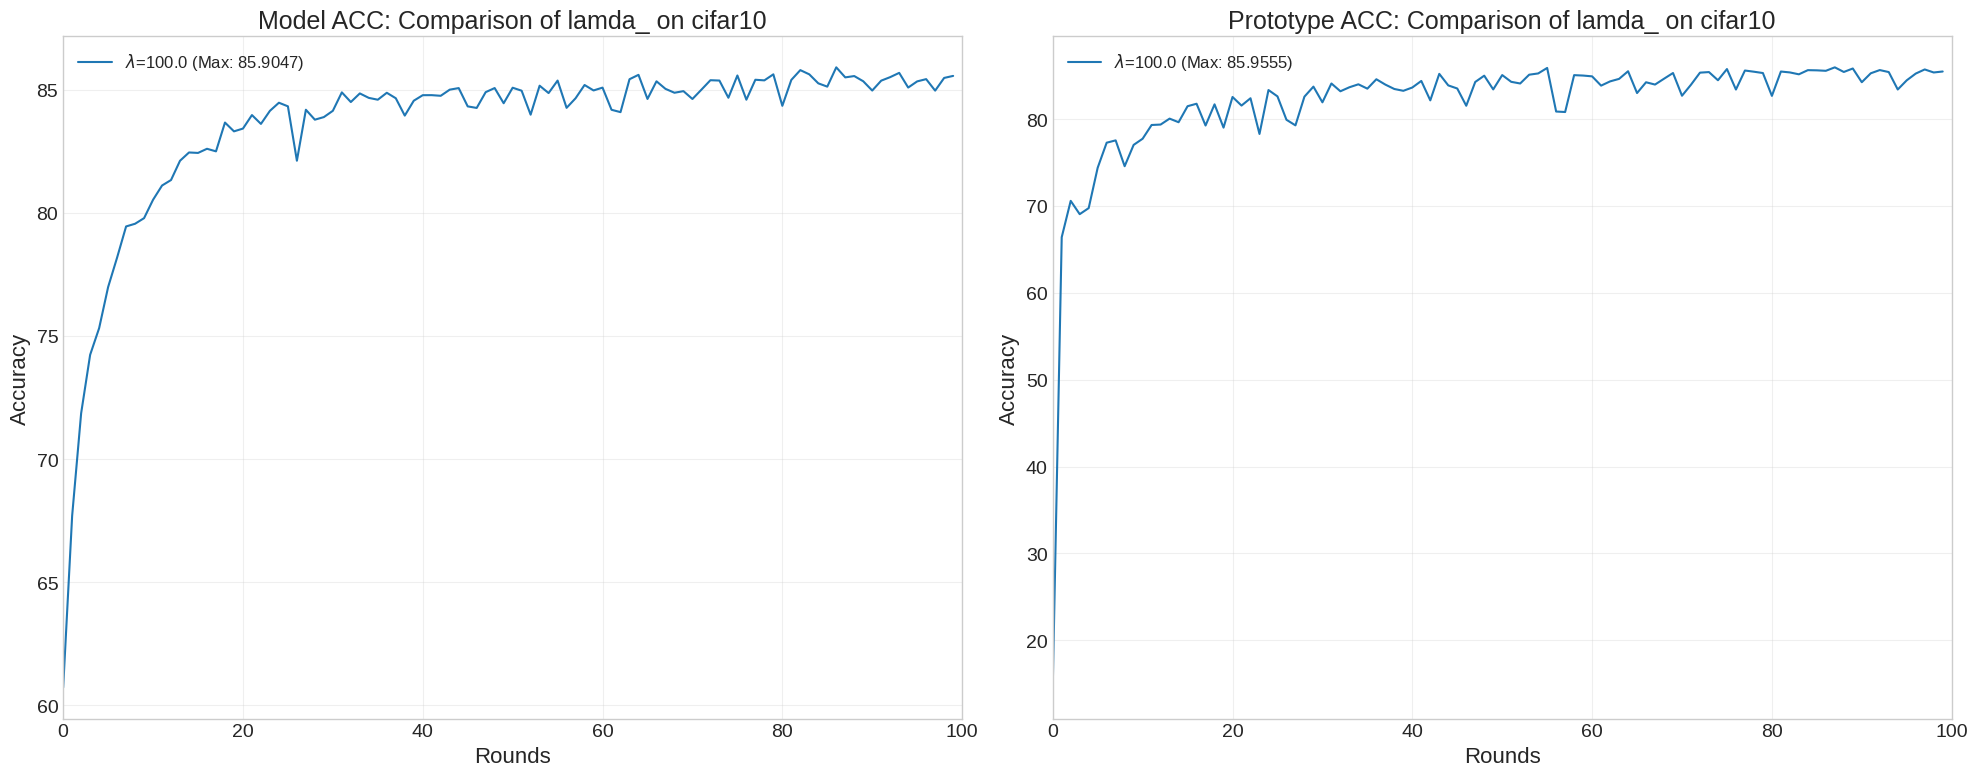

In [10]:
common_args = {
    "dataset": "cifar10",
    "partition": "dirichlet",
    "alpha": 0.1,
    "num_clients": 10,
    "epochs": 1,
    "batch_size": 64,
    "lr": 0.01,
    "head_epochs": 10,
    "body_epochs": 2,
    "lr_head": 0.01,
    "lr_body": 0.01,
    "server_epochs": 100,
    "server_lr": 0.01,
    "margin_threshold": 100.0
}

lambdas = [0.1, 1.0, 10.0, 100.0, 1000.0]
load_and_plot_comparison(algo, "lamda_", lambdas, common_args)

## 单元格 2: Head Epochs 对比

分类头训练轮数影响本地决策边界的稳定性。

Figure saved to figures/split_comparison_of_head_epochs_on_cifar10.png

Summary of ACC:
--------------------------------------------------------------------------------
head_epochs          |    Model Max | Model Last10 |    Proto Max | Proto Last10
--------------------------------------------------------------------------------
2                    |      84.8048 |      84.2592 |      85.2932 |      83.9414
4                    |      85.1045 |      84.5813 |      85.6809 |      84.0811
6                    |      85.4467 |      85.1141 |      85.4607 |      85.1249
8                    |      85.6394 |      85.1269 |      85.9462 |      84.8951
10                   |      85.6243 |      85.1178 |      85.5397 |      84.3930
12                   |      85.9008 |      85.3273 |      85.8829 |      85.0272
14                   |      85.6688 |      85.3124 |      85.6859 |      84.8070
16                   |      85.8433 |      85.4034 |      85.8128 |      85.2712
18                   

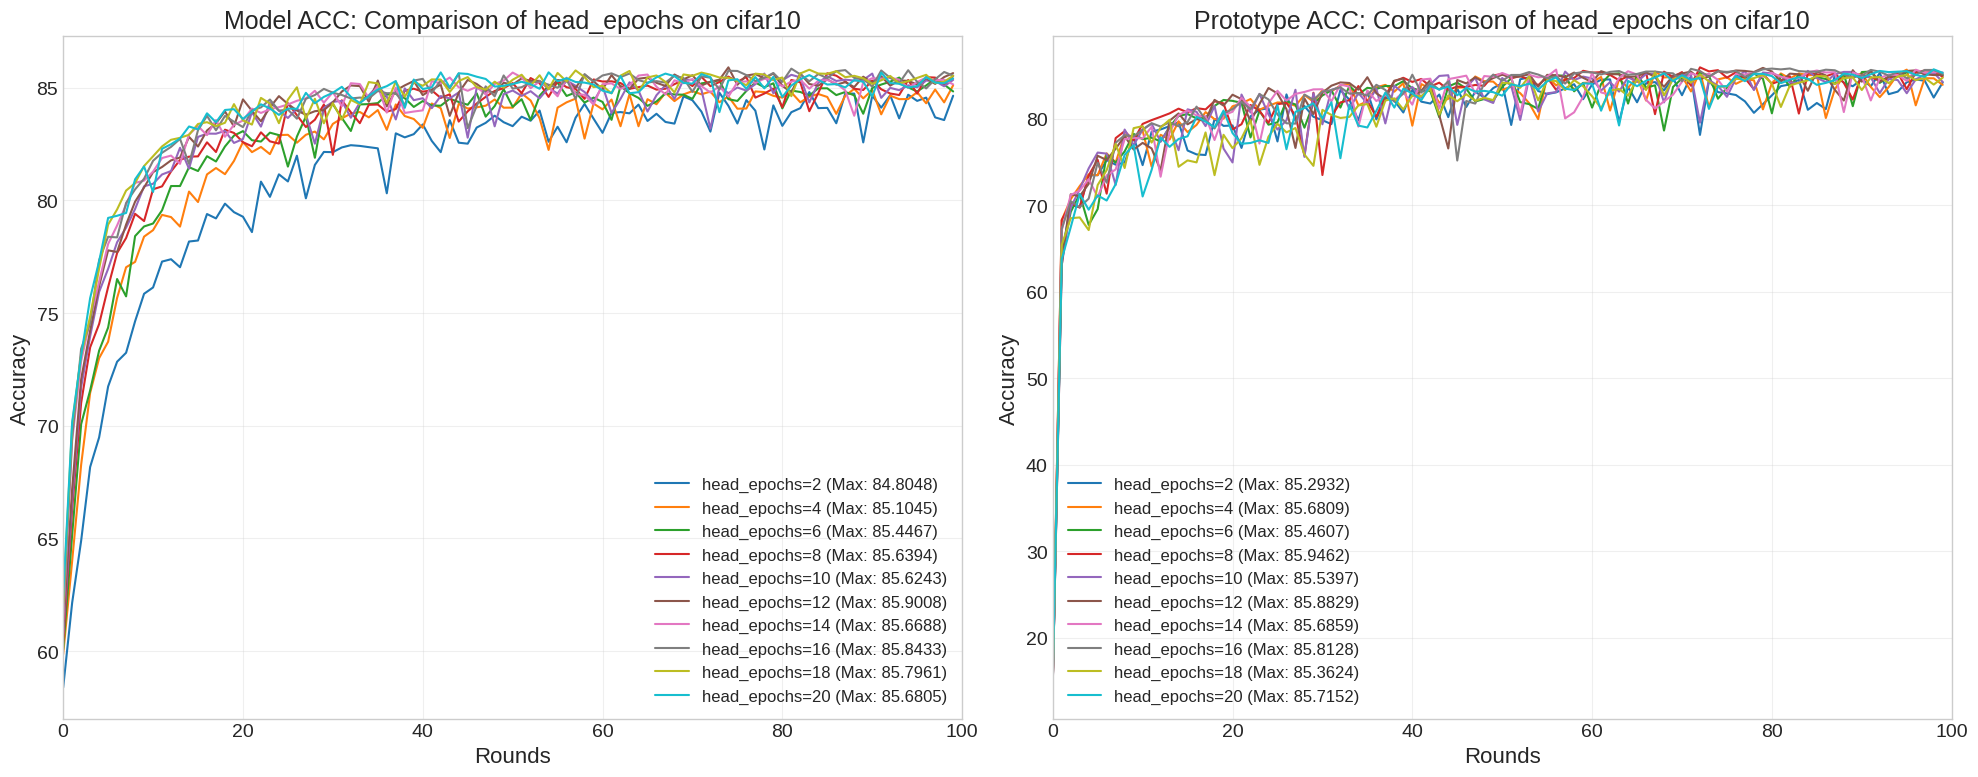

In [18]:
common_args = {
    "dataset": "cifar10",
    "partition": "dirichlet",
    "alpha": 0.1,
    "num_clients": 10,
    "epochs": 1,
    "batch_size": 64,
    "lr": 0.01,
    "lamda_": 100.0,
    "body_epochs": 2,
    "lr_head": 0.01,
    "lr_body": 0.01,
    "server_epochs": 100,
    "server_lr": 0.01,
    "margin_threshold": 100.0
}

heads = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
load_and_plot_comparison(algo, "head_epochs", heads, common_args)

## 单元格 3: Body Epochs 对比

特征提取器（Body）的对齐轮数决定了特征向量向全局原型聚拢的程度。

In [ ]:
common_args = {
    "dataset": "cifar10",
    "partition": "dirichlet",
    "alpha": 0.1,
    "num_clients": 10,
    "epochs": 1,
    "batch_size": 64,
    "lr": 0.01,
    "lamda_": 100.0,
    "head_epochs": 10,
    "lr_head": 0.01,
    "lr_body": 0.01,
    "server_epochs": 100,
    "server_lr": 0.01,
    "margin_threshold": 100.0
}

bodies = [2, 4, 6, 8, 10]
load_and_plot_comparison(algo, "body_epochs", bodies, common_args)

## 单元格 4: Head Learning Rate (lr_head) 对比

分类头的学习率。

In [ ]:
common_args = {
    "dataset": "cifar10",
    "partition": "dirichlet",
    "alpha": 0.1,
    "num_clients": 10,
    "epochs": 1,
    "batch_size": 64,
    "lr": 0.01,
    "lamda_": 10.0,
    "head_epochs": 10,
    "body_epochs": 2,
    "lr_body": 0.01,
    "server_epochs": 100,
    "server_lr": 0.01,
    "margin_threshold": 100.0
}

lr_heads = [0.01]
load_and_plot_comparison(algo, "lr_head", lr_heads, common_args)

## 单元格 5: Body Learning Rate (lr_body) 对比

特征对齐步长。

In [ ]:
common_args = {
    "dataset": "cifar10",
    "partition": "dirichlet",
    "alpha": 0.1,
    "num_clients": 10,
    "epochs": 1,
    "batch_size": 64,
    "lr": 0.01,
    "lamda_": 10.0,
    "head_epochs": 4,
    "body_epochs": 2,
    "lr_head": 0.01,
    "server_epochs": 100,
    "server_lr": 0.01,
    "margin_threshold": 100.0
}

lr_bodies = [0.01]
load_and_plot_comparison(algo, "lr_body", lr_bodies, common_args)

## 单元格 6: Server Epochs 对比

服务端 TGP 网络优化的迭代轮数。

In [ ]:
common_args = {
    "dataset": "cifar10",
    "partition": "dirichlet",
    "alpha": 0.1,
    "num_clients": 10,
    "epochs": 1,
    "batch_size": 64,
    "lr": 0.01,
    "lamda_": 10.0,
    "head_epochs": 4,
    "body_epochs": 2,
    "lr_head": 0.01,
    "lr_body": 0.01,
    "server_lr": 0.01,
    "margin_threshold": 100.0
}

s_epochs = [100]
load_and_plot_comparison(algo, "server_epochs", s_epochs, common_args)

## 单元格 7: Server Learning Rate 对比

服务端 TGP 网络的学习率。

In [ ]:
common_args = {
    "dataset": "cifar10",
    "partition": "dirichlet",
    "alpha": 0.1,
    "num_clients": 10,
    "epochs": 1,
    "batch_size": 64,
    "lr": 0.01,
    "lamda_": 10.0,
    "head_epochs": 4,
    "body_epochs": 2,
    "lr_head": 0.01,
    "lr_body": 0.01,
    "server_epochs": 100,
    "margin_threshold": 100.0
}

s_lrs = [0.01]
load_and_plot_comparison(algo, "server_lr", s_lrs, common_args)

## 单元格 8: Margin Threshold 对比

服务端优化的边际阈值。

In [ ]:
common_args = {
    "dataset": "cifar10",
    "partition": "dirichlet",
    "alpha": 0.1,
    "num_clients": 10,
    "epochs": 1,
    "batch_size": 64,
    "lr": 0.01,
    "lamda_": 10.0,
    "head_epochs": 4,
    "body_epochs": 2,
    "lr_head": 0.01,
    "lr_body": 0.01,
    "server_epochs": 100,
    "server_lr": 0.01
}

margins = [100.0]
load_and_plot_comparison(algo, "margin_threshold", margins, common_args)